In [1]:
from google.colab import files
uploaded = files.upload()

Saving VD_HCC.xlsx to VD_HCC.xlsx


# Chọn đặc trưng

In [ ]:
import numpy as np
import pandas as pd

# 1. CONFIG: CHỌN ĐẶC TRƯNG
SELECTED_FEATURES = ['Platelets', 'AST', 'ALT', 'Total_Bil', 'HBsAg', 'CEA', 'AFP', 'CA19-9', 'APRI', 'FIB-4', 'Age', 'Gender']

# 2. LOAD DATA
df = pd.read_excel("VD_HCC.xlsx")

# Chỉ lấy feature đã chọn
X = df[SELECTED_FEATURES]
y = df["label"]

# Tách theo lớp
X_hcc = X[y == 1]
y_hcc = y[y == 1]

X_non = X[y == 0]
y_non = y[y == 0]

# Random Forest (N=30)

In [ ]:
# Tính acc, pre, rec, f1, roc, pr-auc cho tập train, test theo features subset =========================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
# =========================================================
# 3. HÀM K-FOLD TRÊN TRAIN (CÓ ROC-AUC + PR-AUC)
# =========================================================
def kfold_train_evaluate(X_train, y_train, k=10):

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    acc_list, pre_list, rec_list, f1_list = [], [], [], []
    auc_list, pr_list = [], []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42
        )

        model.fit(X_tr, y_tr)

        # Predict
        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)[:, 1]

        # Metrics
        acc_list.append(accuracy_score(y_val, y_pred))
        pre_list.append(precision_score(y_val, y_pred, zero_division=0))
        rec_list.append(recall_score(y_val, y_pred))
        f1_list.append(f1_score(y_val, y_pred))

        auc_list.append(roc_auc_score(y_val, y_prob))
        pr_list.append(average_precision_score(y_val, y_prob))

    return (
        np.mean(acc_list),
        np.mean(pre_list),
        np.mean(rec_list),
        np.mean(f1_list),
        np.mean(auc_list),
        np.mean(pr_list)
    )

# =========================================================
# 4. MAIN LOOP (30 RUNS)
# =========================================================
N_RUNS = 30

train_metrics_all = []
test_metrics_all = []

for run in range(N_RUNS):

    # print(f"\n========== RUN {run+1} ==========")

    # ---------------- Controlled Sampling ----------------
    hcc_idx = np.random.permutation(len(X_hcc))
    non_idx = np.random.permutation(len(X_non))

    # Train
    X_train = pd.concat([
        X_hcc.iloc[hcc_idx[:295]],
        X_non.iloc[non_idx[:409]]
    ])
    y_train = pd.concat([
        y_hcc.iloc[hcc_idx[:295]],
        y_non.iloc[non_idx[:409]]
    ])

    # Test
    X_test = pd.concat([
        X_hcc.iloc[hcc_idx[295:303]],
        X_non.iloc[non_idx[409:577]]
    ])
    y_test = pd.concat([
        y_hcc.iloc[hcc_idx[295:303]],
        y_non.iloc[non_idx[409:577]]
    ])

    # Shuffle
    idx_train = np.random.permutation(len(X_train))
    idx_test = np.random.permutation(len(X_test))

    X_train, y_train = X_train.iloc[idx_train], y_train.iloc[idx_train]
    X_test, y_test = X_test.iloc[idx_test], y_test.iloc[idx_test]

    # =====================================================
    # 4.1 K-FOLD TRÊN TRAIN
    # =====================================================
    train_metrics = kfold_train_evaluate(X_train, y_train, k=10)

    # print("\n[TRAIN - 10-FOLD CV]")
    # print(f"Accuracy : {train_metrics[0]:.4f}")
    # print(f"Precision: {train_metrics[1]:.4f}")
    # print(f"Recall   : {train_metrics[2]:.4f}")
    # print(f"F1-score : {train_metrics[3]:.4f}")
    # print(f"ROC-AUC  : {train_metrics[4]:.4f}")
    # print(f"PR-AUC   : {train_metrics[5]:.4f}")

    train_metrics_all.append(train_metrics)

    # =====================================================
    # 4.2 TRAIN FULL MODEL
    # =====================================================
    model = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # =====================================================
    # 4.3 TEST METRICS
    # =====================================================
    test_acc = accuracy_score(y_test, y_pred)
    test_pre = precision_score(y_test, y_pred, zero_division=0)
    test_rec = recall_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred)

    test_auc = roc_auc_score(y_test, y_prob)
    test_pr  = average_precision_score(y_test, y_prob)

    # print("\n[TEST]")
    # print(f"Accuracy : {test_acc:.4f}")
    # print(f"Precision: {test_pre:.4f}")
    # print(f"Recall   : {test_rec:.4f}")
    # print(f"F1-score : {test_f1:.4f}")
    # print(f"ROC-AUC  : {test_auc:.4f}")
    # print(f"PR-AUC   : {test_pr:.4f}")

    test_metrics_all.append([
        test_acc, test_pre, test_rec, test_f1, test_auc, test_pr
    ])

# =========================================================
# 5. TỔNG HỢP KẾT QUẢ
# =========================================================
train_metrics_all = np.array(train_metrics_all)
test_metrics_all = np.array(test_metrics_all)

metrics_name = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]

print("\n================ FINAL RESULTS RF================\n")
print("---- TRAIN (10-FOLD CV) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {train_metrics_all[:, i].mean():.4f} ± {train_metrics_all[:, i].std():.4f}")

print("\n---- TEST (Loop N=30) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {test_metrics_all[:, i].mean():.4f} ± {test_metrics_all[:, i].std():.4f}")


================ FINAL RESULTS RF================

---- TRAIN (10-FOLD CV) ----
Accuracy: 0.9203 ± 0.0065
Precision: 0.9053 ± 0.0108
Recall: 0.9073 ± 0.0083
F1-score: 0.9050 ± 0.0077
ROC-AUC: 0.9675 ± 0.0023
PR-AUC: 0.9657 ± 0.0032

---- TEST (Loop N=30) ----
Accuracy: 0.9265 ± 0.0183
Precision: 0.3819 ± 0.0700
Recall: 0.9042 ± 0.1004
F1-score: 0.5337 ± 0.0769
ROC-AUC: 0.9656 ± 0.0389
PR-AUC: 0.8179 ± 0.0942


# XGBoost

In [ ]:
# Tính acc, pre, rec, f1, roc, pr-auc cho tập train, test theo features subset =========================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
# =========================================================
# 3. HÀM K-FOLD TRÊN TRAIN (CÓ ROC-AUC + PR-AUC)
# =========================================================
def kfold_train_evaluate(X_train, y_train, k=10):

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    acc_list, pre_list, rec_list, f1_list = [], [], [], []
    auc_list, pr_list = [], []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Tính toán trọng số cân bằng cho tập y_tr hiện tại
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_tr)

        model = XGBClassifier(
            n_estimators=200,
            random_state=42,
            eval_metric='logloss' # Tránh cảnh báo của phiên bản XGBoost mới
        )

        # Đưa trọng số vào huấn luyện thay cho class_weight="balanced"
        model.fit(X_tr, y_tr, sample_weight=sample_weights)

        # Predict
        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)[:, 1]

        # Metrics
        acc_list.append(accuracy_score(y_val, y_pred))
        pre_list.append(precision_score(y_val, y_pred, zero_division=0))
        rec_list.append(recall_score(y_val, y_pred))
        f1_list.append(f1_score(y_val, y_pred))

        auc_list.append(roc_auc_score(y_val, y_prob))
        pr_list.append(average_precision_score(y_val, y_prob))

    return (
        np.mean(acc_list),
        np.mean(pre_list),
        np.mean(rec_list),
        np.mean(f1_list),
        np.mean(auc_list),
        np.mean(pr_list)
    )

# =========================================================
# 4. MAIN LOOP (30 RUNS)
# =========================================================
N_RUNS = 30

train_metrics_all = []
test_metrics_all = []

for run in range(N_RUNS):

    # print(f"\n========== RUN {run+1} ==========")

    # ---------------- Controlled Sampling ----------------
    hcc_idx = np.random.permutation(len(X_hcc))
    non_idx = np.random.permutation(len(X_non))

    # Train
    X_train = pd.concat([
        X_hcc.iloc[hcc_idx[:295]],
        X_non.iloc[non_idx[:409]]
    ])
    y_train = pd.concat([
        y_hcc.iloc[hcc_idx[:295]],
        y_non.iloc[non_idx[:409]]
    ])

    # Test
    X_test = pd.concat([
        X_hcc.iloc[hcc_idx[295:303]],
        X_non.iloc[non_idx[409:577]]
    ])
    y_test = pd.concat([
        y_hcc.iloc[hcc_idx[295:303]],
        y_non.iloc[non_idx[409:577]]
    ])

    # Shuffle
    idx_train = np.random.permutation(len(X_train))
    idx_test = np.random.permutation(len(X_test))

    X_train, y_train = X_train.iloc[idx_train], y_train.iloc[idx_train]
    X_test, y_test = X_test.iloc[idx_test], y_test.iloc[idx_test]

    # =====================================================
    # 4.1 K-FOLD TRÊN TRAIN
    # =====================================================
    train_metrics = kfold_train_evaluate(X_train, y_train, k=10)

    train_metrics_all.append(train_metrics)

    # =====================================================
    # 4.2 TRAIN FULL MODEL
    # =====================================================

    # Tính trọng số cân bằng cho toàn bộ tập y_train
    sample_weights_full = compute_sample_weight(class_weight='balanced', y=y_train)

    model = XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric='logloss'
    )

    model.fit(X_train, y_train, sample_weight=sample_weights_full)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # =====================================================
    # 4.3 TEST METRICS
    # =====================================================
    test_acc = accuracy_score(y_test, y_pred)
    test_pre = precision_score(y_test, y_pred, zero_division=0)
    test_rec = recall_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred)

    test_auc = roc_auc_score(y_test, y_prob)
    test_pr  = average_precision_score(y_test, y_prob)

    test_metrics_all.append([
        test_acc, test_pre, test_rec, test_f1, test_auc, test_pr
    ])

# =========================================================
# 5. TỔNG HỢP KẾT QUẢ
# =========================================================
train_metrics_all = np.array(train_metrics_all)
test_metrics_all = np.array(test_metrics_all)

metrics_name = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]

# Đổi tiêu đề thành XGBOOST
print("\n================ FINAL RESULTS XGBOOST ================\n")
print("---- TRAIN (10-FOLD CV) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {train_metrics_all[:, i].mean():.4f} ± {train_metrics_all[:, i].std():.4f}")

print("\n---- TEST (Loop N=30) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {test_metrics_all[:, i].mean():.4f} ± {test_metrics_all[:, i].std():.4f}")


================ FINAL RESULTS XGBOOST ================

---- TRAIN (10-FOLD CV) ----
Accuracy: 0.9243 ± 0.0052
Precision: 0.9102 ± 0.0083
Recall: 0.9118 ± 0.0070
F1-score: 0.9098 ± 0.0062
ROC-AUC: 0.9666 ± 0.0037
PR-AUC: 0.9663 ± 0.0042

---- TEST (Loop N=30) ----
Accuracy: 0.9371 ± 0.0138
Precision: 0.4168 ± 0.0628
Recall: 0.8792 ± 0.0994
F1-score: 0.5629 ± 0.0686
ROC-AUC: 0.9620 ± 0.0433
PR-AUC: 0.8134 ± 0.0900


# Adaboost

In [ ]:
# Tính acc, pre, rec, f1, roc, pr-auc cho tập train, test theo features subset =========================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.impute import SimpleImputer # Import SimpleImputer

# =========================================================
# 3. HÀM K-FOLD TRÊN TRAIN (CÓ ROC-AUC + PR-AUC)
# =========================================================
def kfold_train_evaluate(X_train, y_train, k=10):

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    acc_list, pre_list, rec_list, f1_list = [], [], [], []
    auc_list, pr_list = [], []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Xử lý missing values (Imputation)
        imputer = SimpleImputer(strategy='mean')
        X_tr_imputed = imputer.fit_transform(X_tr)
        X_val_imputed = imputer.transform(X_val)

        # Tính toán trọng số cân bằng cho tập y_tr hiện tại
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_tr)

        # Khởi tạo mô hình AdaBoost (Mặc định dùng Decision Stump làm base estimator)
        model = AdaBoostClassifier(
            n_estimators=200,
            random_state=42
        )

        # Đưa trọng số ban đầu vào hàm fit
        model.fit(X_tr_imputed, y_tr, sample_weight=sample_weights)

        # Predict
        y_pred = model.predict(X_val_imputed)
        y_prob = model.predict_proba(X_val_imputed)[:, 1]

        # Metrics
        acc_list.append(accuracy_score(y_val, y_pred))
        pre_list.append(precision_score(y_val, y_pred, zero_division=0))
        rec_list.append(recall_score(y_val, y_pred))
        f1_list.append(f1_score(y_val, y_pred))

        auc_list.append(roc_auc_score(y_val, y_prob))
        pr_list.append(average_precision_score(y_val, y_prob))

    return (
        np.mean(acc_list),
        np.mean(pre_list),
        np.mean(rec_list),
        np.mean(f1_list),
        np.mean(auc_list),
        np.mean(pr_list)
    )

# =========================================================
# 4. MAIN LOOP (30 RUNS)
# =========================================================
N_RUNS = 30

train_metrics_all = []
test_metrics_all = []

for run in range(N_RUNS):

    # print(f"\n========== RUN {run+1} ==========")

    # ---------------- Controlled Sampling ----------------
    hcc_idx = np.random.permutation(len(X_hcc))
    non_idx = np.random.permutation(len(X_non))

    # Train
    X_train = pd.concat([
        X_hcc.iloc[hcc_idx[:295]],
        X_non.iloc[non_idx[:409]]
    ])
    y_train = pd.concat([
        y_hcc.iloc[hcc_idx[:295]],
        y_non.iloc[non_idx[:409]]
    ])

    # Test
    X_test = pd.concat([
        X_hcc.iloc[hcc_idx[295:303]],
        X_non.iloc[non_idx[409:577]]
    ])
    y_test = pd.concat([
        y_hcc.iloc[hcc_idx[295:303]],
        y_non.iloc[non_idx[409:577]]
    ])

    # Shuffle
    idx_train = np.random.permutation(len(X_train))
    idx_test = np.random.permutation(len(X_test))

    X_train, y_train = X_train.iloc[idx_train], y_train.iloc[idx_train]
    X_test, y_test = X_test.iloc[idx_test], y_test.iloc[idx_test]

    # =====================================================
    # 4.1 K-FOLD TRÊN TRAIN
    # =====================================================
    train_metrics = kfold_train_evaluate(X_train, y_train, k=10)

    train_metrics_all.append(train_metrics)

    # =====================================================
    # 4.2 TRAIN FULL MODEL
    # =====================================================

    # Xử lý missing values trên toàn bộ tập X_train trước khi huấn luyện
    imputer_full = SimpleImputer(strategy='mean')
    X_train_imputed = imputer_full.fit_transform(X_train)
    X_test_imputed = imputer_full.transform(X_test)

    # Tính trọng số cân bằng cho toàn bộ tập y_train
    sample_weights_full = compute_sample_weight(class_weight='balanced', y=y_train)

    model = AdaBoostClassifier(
        n_estimators=200,
        random_state=42
    )

    # Truyền trọng số vào hàm fit
    model.fit(X_train_imputed, y_train, sample_weight=sample_weights_full)

    y_pred = model.predict(X_test_imputed)
    y_prob = model.predict_proba(X_test_imputed)[:, 1]

    # =====================================================
    # 4.3 TEST METRICS
    # =====================================================
    test_acc = accuracy_score(y_test, y_pred)
    test_pre = precision_score(y_test, y_pred, zero_division=0)
    test_rec = recall_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred)

    test_auc = roc_auc_score(y_test, y_prob)
    test_pr  = average_precision_score(y_test, y_prob)

    test_metrics_all.append([
        test_acc, test_pre, test_rec, test_f1, test_auc, test_pr
    ])

# =========================================================
# 5. TỔNG HỢP KẾT QUẢ
# =========================================================
train_metrics_all = np.array(train_metrics_all)
test_metrics_all = np.array(test_metrics_all)

metrics_name = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]

print("\n================ FINAL RESULTS ADABOOST ================\n")
print("---- TRAIN (10-FOLD CV) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {train_metrics_all[:, i].mean():.4f} ± {train_metrics_all[:, i].std():.4f}")

print("\n---- TEST (Loop N=30) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {test_metrics_all[:, i].mean():.4f} ± {test_metrics_all[:, i].std():.4f}")


================ FINAL RESULTS ADABOOST ================

---- TRAIN (10-FOLD CV) ----
Accuracy: 0.9116 ± 0.0060
Precision: 0.8966 ± 0.0098
Recall: 0.8956 ± 0.0081
F1-score: 0.8946 ± 0.0073
ROC-AUC: 0.9609 ± 0.0042
PR-AUC: 0.9571 ± 0.0056

---- TEST (Loop N=30) ----
Accuracy: 0.9206 ± 0.0152
Precision: 0.3579 ± 0.0593
Recall: 0.8958 ± 0.0973
F1-score: 0.5097 ± 0.0698
ROC-AUC: 0.9561 ± 0.0564
PR-AUC: 0.7439 ± 0.1379


#LightGBM

In [ ]:
# Tính acc, pre, rec, f1, roc, pr-auc cho tập train, test theo features subset =========================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
# =========================================================
# 3. HÀM K-FOLD TRÊN TRAIN (CÓ ROC-AUC + PR-AUC)
# =========================================================
def kfold_train_evaluate(X_train, y_train, k=10):

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    acc_list, pre_list, rec_list, f1_list = [], [], [], []
    auc_list, pr_list = [], []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Khởi tạo mô hình LightGBM (Hỗ trợ sẵn class_weight="balanced")
        model = LGBMClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            verbose=-1 # Tắt các log cảnh báo của LightGBM trong quá trình train
        )

        model.fit(X_tr, y_tr)

        # Predict
        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)[:, 1]

        # Metrics
        acc_list.append(accuracy_score(y_val, y_pred))
        pre_list.append(precision_score(y_val, y_pred, zero_division=0))
        rec_list.append(recall_score(y_val, y_pred))
        f1_list.append(f1_score(y_val, y_pred))

        auc_list.append(roc_auc_score(y_val, y_prob))
        pr_list.append(average_precision_score(y_val, y_prob))

    return (
        np.mean(acc_list),
        np.mean(pre_list),
        np.mean(rec_list),
        np.mean(f1_list),
        np.mean(auc_list),
        np.mean(pr_list)
    )

# =========================================================
# 4. MAIN LOOP (30 RUNS)
# =========================================================
N_RUNS = 30

train_metrics_all = []
test_metrics_all = []

for run in range(N_RUNS):

    # print(f"\n========== RUN {run+1} ==========")

    # ---------------- Controlled Sampling ----------------
    hcc_idx = np.random.permutation(len(X_hcc))
    non_idx = np.random.permutation(len(X_non))

    # Train
    X_train = pd.concat([
        X_hcc.iloc[hcc_idx[:295]],
        X_non.iloc[non_idx[:409]]
    ])
    y_train = pd.concat([
        y_hcc.iloc[hcc_idx[:295]],
        y_non.iloc[non_idx[:409]]
    ])

    # Test
    X_test = pd.concat([
        X_hcc.iloc[hcc_idx[295:303]],
        X_non.iloc[non_idx[409:577]]
    ])
    y_test = pd.concat([
        y_hcc.iloc[hcc_idx[295:303]],
        y_non.iloc[non_idx[409:577]]
    ])

    # Shuffle
    idx_train = np.random.permutation(len(X_train))
    idx_test = np.random.permutation(len(X_test))

    X_train, y_train = X_train.iloc[idx_train], y_train.iloc[idx_train]
    X_test, y_test = X_test.iloc[idx_test], y_test.iloc[idx_test]

    # =====================================================
    # 4.1 K-FOLD TRÊN TRAIN
    # =====================================================
    train_metrics = kfold_train_evaluate(X_train, y_train, k=10)

    train_metrics_all.append(train_metrics)

    # =====================================================
    # 4.2 TRAIN FULL MODEL
    # =====================================================
    model = LGBMClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # =====================================================
    # 4.3 TEST METRICS
    # =====================================================
    test_acc = accuracy_score(y_test, y_pred)
    test_pre = precision_score(y_test, y_pred, zero_division=0)
    test_rec = recall_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred)

    test_auc = roc_auc_score(y_test, y_prob)
    test_pr  = average_precision_score(y_test, y_prob)

    test_metrics_all.append([
        test_acc, test_pre, test_rec, test_f1, test_auc, test_pr
    ])

# =========================================================
# 5. TỔNG HỢP KẾT QUẢ
# =========================================================
train_metrics_all = np.array(train_metrics_all)
test_metrics_all = np.array(test_metrics_all)

metrics_name = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]

print("\n================ FINAL RESULTS LIGHTGBM ================\n")
print("---- TRAIN (10-FOLD CV) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {train_metrics_all[:, i].mean():.4f} ± {train_metrics_all[:, i].std():.4f}")

print("\n---- TEST (Loop N=30) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {test_metrics_all[:, i].mean():.4f} ± {test_metrics_all[:, i].std():.4f}")


================ FINAL RESULTS LIGHTGBM ================

---- TRAIN (10-FOLD CV) ----
Accuracy: 0.9229 ± 0.0062
Precision: 0.9100 ± 0.0099
Recall: 0.9085 ± 0.0083
F1-score: 0.9080 ± 0.0071
ROC-AUC: 0.9687 ± 0.0035
PR-AUC: 0.9682 ± 0.0035

---- TEST (Loop N=30) ----
Accuracy: 0.9347 ± 0.0175
Precision: 0.4148 ± 0.0740
Recall: 0.9208 ± 0.0994
F1-score: 0.5676 ± 0.0746
ROC-AUC: 0.9625 ± 0.0461
PR-AUC: 0.8255 ± 0.1155


# Ensemble model

In [ ]:
# Tính acc, pre, rec, f1, roc, pr-auc cho tập train, test theo features subset =========================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
# =========================================================
# 3. HÀM K-FOLD TRÊN TRAIN (CÓ ROC-AUC + PR-AUC)
# =========================================================
def kfold_train_evaluate(X_train, y_train, k=10):

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    acc_list, pre_list, rec_list, f1_list = [], [], [], []
    auc_list, pr_list = [], []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # ---------------------------------------------------------
        # XỬ LÝ DỮ LIỆU THIẾU (Bắt buộc cho RF và AdaBoost)
        # ---------------------------------------------------------
        imputer = SimpleImputer(strategy='median')
        X_tr_imputed = imputer.fit_transform(X_tr)
        X_val_imputed = imputer.transform(X_val)

        # Tính toán trọng số cân bằng
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_tr)

        # ---------------------------------------------------------
        # KHỞI TẠO 3 MÔ HÌNH CON
        # ---------------------------------------------------------
        # Lưu ý: Giảm n_estimators xuống 100 nếu quá trình chạy 30 runs quá chậm
        rf = RandomForestClassifier(n_estimators=200, random_state=42)
        xgb = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
        ada = AdaBoostClassifier(n_estimators=200, random_state=42)

        # ---------------------------------------------------------
        # GỘP THÀNH ENSEMBLE BẰNG VOTING CLASSIFIER
        # Bắt buộc voting='soft' để lấy được xác suất (predict_proba)
        # ---------------------------------------------------------
        ensemble_model = VotingClassifier(
            estimators=[
                ('rf', rf),
                ('xgb', xgb),
                ('ada', ada)
            ],
            voting='soft'
        )

        # Truyền trọng số vào hàm fit, VotingClassifier sẽ tự động chia cho 3 model con
        ensemble_model.fit(X_tr_imputed, y_tr, sample_weight=sample_weights)

        # Predict
        y_pred = ensemble_model.predict(X_val_imputed)
        y_prob = ensemble_model.predict_proba(X_val_imputed)[:, 1]

        # Metrics
        acc_list.append(accuracy_score(y_val, y_pred))
        pre_list.append(precision_score(y_val, y_pred, zero_division=0))
        rec_list.append(recall_score(y_val, y_pred))
        f1_list.append(f1_score(y_val, y_pred))

        auc_list.append(roc_auc_score(y_val, y_prob))
        pr_list.append(average_precision_score(y_val, y_prob))

    return (
        np.mean(acc_list),
        np.mean(pre_list),
        np.mean(rec_list),
        np.mean(f1_list),
        np.mean(auc_list),
        np.mean(pr_list)
    )

# =========================================================
# 4. MAIN LOOP (30 RUNS)
# =========================================================
N_RUNS = 30

train_metrics_all = []
test_metrics_all = []

for run in range(N_RUNS):

    # print(f"\n========== RUN {run+1} ==========")

    # ---------------- Controlled Sampling ----------------
    hcc_idx = np.random.permutation(len(X_hcc))
    non_idx = np.random.permutation(len(X_non))

    # Train
    X_train = pd.concat([
        X_hcc.iloc[hcc_idx[:295]],
        X_non.iloc[non_idx[:409]]
    ])
    y_train = pd.concat([
        y_hcc.iloc[hcc_idx[:295]],
        y_non.iloc[non_idx[:409]]
    ])

    # Test
    X_test = pd.concat([
        X_hcc.iloc[hcc_idx[295:303]],
        X_non.iloc[non_idx[409:577]]
    ])
    y_test = pd.concat([
        y_hcc.iloc[hcc_idx[295:303]],
        y_non.iloc[non_idx[409:577]]
    ])

    # Shuffle
    idx_train = np.random.permutation(len(X_train))
    idx_test = np.random.permutation(len(X_test))

    X_train, y_train = X_train.iloc[idx_train], y_train.iloc[idx_train]
    X_test, y_test = X_test.iloc[idx_test], y_test.iloc[idx_test]

    # =====================================================
    # 4.1 K-FOLD TRÊN TRAIN
    # =====================================================
    train_metrics = kfold_train_evaluate(X_train, y_train, k=10)
    train_metrics_all.append(train_metrics)

    # =====================================================
    # 4.2 TRAIN FULL MODEL
    # =====================================================

    # Impute cho tập Full
    imputer_full = SimpleImputer(strategy='median')
    X_train_imputed = imputer_full.fit_transform(X_train)
    X_test_imputed = imputer_full.transform(X_test)

    # Tính trọng số cân bằng cho toàn bộ tập y_train
    sample_weights_full = compute_sample_weight(class_weight='balanced', y=y_train)

    rf_full = RandomForestClassifier(n_estimators=200, random_state=42)
    xgb_full = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
    ada_full = AdaBoostClassifier(n_estimators=200, random_state=42)

    ensemble_model_full = VotingClassifier(
        estimators=[('rf', rf_full), ('xgb', xgb_full), ('ada', ada_full)],
        voting='soft'
    )

    # Truyền trọng số vào hàm fit
    ensemble_model_full.fit(X_train_imputed, y_train, sample_weight=sample_weights_full)

    y_pred = ensemble_model_full.predict(X_test_imputed)
    y_prob = ensemble_model_full.predict_proba(X_test_imputed)[:, 1]

    # =====================================================
    # 4.3 TEST METRICS
    # =====================================================
    test_acc = accuracy_score(y_test, y_pred)
    test_pre = precision_score(y_test, y_pred, zero_division=0)
    test_rec = recall_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred)

    test_auc = roc_auc_score(y_test, y_prob)
    test_pr  = average_precision_score(y_test, y_prob)

    test_metrics_all.append([
        test_acc, test_pre, test_rec, test_f1, test_auc, test_pr
    ])

# =========================================================
# 5. TỔNG HỢP KẾT QUẢ
# =========================================================
train_metrics_all = np.array(train_metrics_all)
test_metrics_all = np.array(test_metrics_all)

metrics_name = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]

print("\n================ FINAL RESULTS VOTING ENSEMBLE (RF + XGB + ADA) ================\n")
print("---- TRAIN (10-FOLD CV) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {train_metrics_all[:, i].mean():.4f} ± {train_metrics_all[:, i].std():.4f}")

print("\n---- TEST (Loop N=30) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {test_metrics_all[:, i].mean():.4f} ± {test_metrics_all[:, i].std():.4f}")


================ FINAL RESULTS VOTING ENSEMBLE (RF + XGB + ADA) ================

---- TRAIN (10-FOLD CV) ----
Accuracy: 0.9267 ± 0.0046
Precision: 0.9148 ± 0.0073
Recall: 0.9124 ± 0.0079
F1-score: 0.9124 ± 0.0054
ROC-AUC: 0.9676 ± 0.0024
PR-AUC: 0.9680 ± 0.0027

---- TEST (Loop N=30) ----
Accuracy: 0.9335 ± 0.0191
Precision: 0.4103 ± 0.0914
Recall: 0.9000 ± 0.1225
F1-score: 0.5587 ± 0.0945
ROC-AUC: 0.9644 ± 0.0330
PR-AUC: 0.7990 ± 0.0884


# Vẽ ROC-AUC và PR-AUC

Running: All-features
Running: ML-selected
Running: Expert
Running: ML+Expert


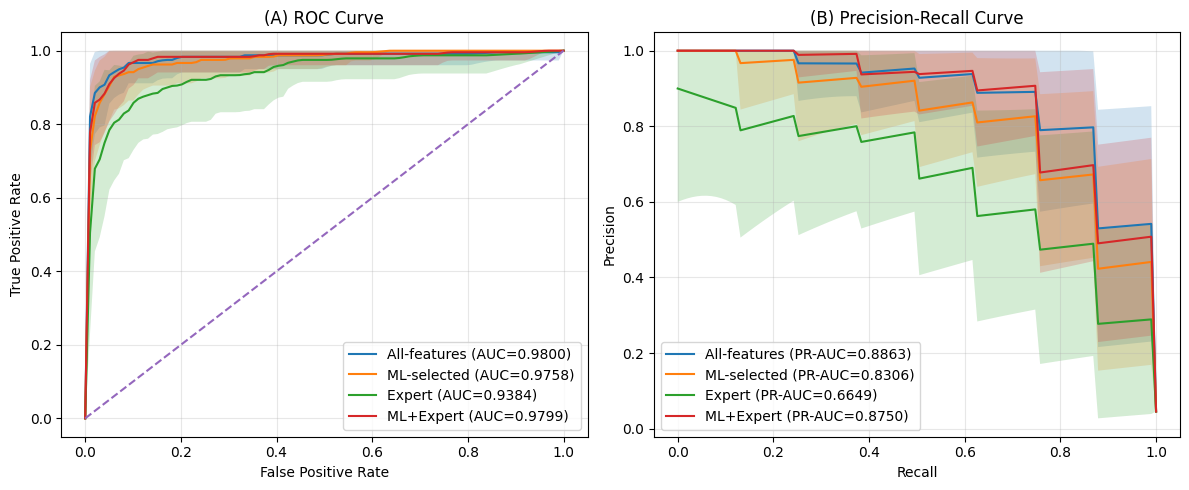

In [ ]:
# Vẽ ROC-AUC, PR-AUC theo các subset =========================================================
# 0. IMPORT
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

# =========================================================
# 1. FEATURE SUBSETS
# =========================================================

FEATURE_SETS = {
    "All-features":['Age', 'Gender', 'Platelets', 'INR', 'AST', 'ALT', 'Total_Bil', 'Dir_Bil', 'Albumin', 'Ure', 'Creatinine', 'Glucose', 'HBsAg', 'HCVAb', 'CEA', 'AFP', 'CA19-9', 'AST/ALT', 'APRI', 'FIB-4'],
    "ML-selected":['Platelets', 'AST', 'AFP', 'Total_Bil', 'APRI', 'FIB-4', 'HBsAg', 'ALT', 'CEA', 'CA19-9'],
    "Expert":['Age', 'AST', 'AFP', 'Gender', 'ALT', 'HBsAg'],
    "ML+Expert":['Age', 'Platelets', 'AST', 'AFP', 'Total_Bil', 'APRI', 'FIB-4', 'HBsAg', 'ALT', 'Gender', 'CEA', 'CA19-9']
}

# =========================================================
# 2. LOAD DATA
# =========================================================
df = pd.read_excel("data_hcc_may.xlsx")
y = df["label"]

# =========================================================
# 3. CONFIG
# =========================================================
N_RUNS = 30
mean_fpr = np.linspace(0, 1, 100)
mean_recall = np.linspace(0, 1, 100)

# =========================================================
# 4. HÀM CHẠY 1 FEATURE SET
# =========================================================
def evaluate_feature_set(feature_list):

    X = df[feature_list]

    X_hcc = X[y == 1]
    X_non = X[y == 0]

    y_hcc = y[y == 1]
    y_non = y[y == 0]

    tprs = []
    prs = []

    aucs = []
    pr_aucs = []

    for run in range(N_RUNS):

        # -------- Controlled Sampling --------
        hcc_idx = np.random.permutation(len(X_hcc))
        non_idx = np.random.permutation(len(X_non))

        # Train
        X_train = pd.concat([
          X_hcc.iloc[hcc_idx[:295]],
          X_non.iloc[non_idx[:409]]
        ])
        y_train = pd.concat([
          y_hcc.iloc[hcc_idx[:295]],
          y_non.iloc[non_idx[:409]]
        ])

        # Test
        X_test = pd.concat([
          X_hcc.iloc[hcc_idx[295:303]],
          X_non.iloc[non_idx[409:577]]
        ])
        y_test = pd.concat([
          y_hcc.iloc[hcc_idx[295:303]],
          y_non.iloc[non_idx[409:577]]
        ])

        # Shuffle
        idx_train = np.random.permutation(len(X_train))
        idx_test = np.random.permutation(len(X_test))

        X_train, y_train = X_train.iloc[idx_train], y_train.iloc[idx_train]
        X_test, y_test = X_test.iloc[idx_test], y_test.iloc[idx_test]

        # -------- Model --------
        model = RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42
        )
        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:, 1]

        # -------- ROC --------
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0
        tprs.append(interp_tpr)

        aucs.append(roc_auc_score(y_test, y_prob))

        # -------- PR --------
        precision, recall, _ = precision_recall_curve(y_test, y_prob)

        precision = precision[::-1]
        recall = recall[::-1]

        interp_pr = np.interp(mean_recall, recall, precision)
        prs.append(interp_pr)

        pr_aucs.append(average_precision_score(y_test, y_prob))

    # -------- Mean --------
    return {
        "mean_tpr": np.mean(tprs, axis=0),
        "std_tpr": np.std(tprs, axis=0),
        "mean_pr": np.mean(prs, axis=0),
        "std_pr": np.std(prs, axis=0),
        "auc_mean": np.mean(aucs),
        "auc_std": np.std(aucs),
        "pr_auc_mean": np.mean(pr_aucs),
        "pr_auc_std": np.std(pr_aucs)
    }

# =========================================================
# 5. CHẠY TẤT CẢ FEATURE SETS
# =========================================================
results = {}

for name, features in FEATURE_SETS.items():
    print(f"Running: {name}")
    results[name] = evaluate_feature_set(features)

# =========================================================
# 6. VẼ ROC + PR OVERLAY
# =========================================================
import matplotlib.pyplot as plt

# TẠO FIGURE 2 PANEL
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax_roc = axes[0]
ax_pr = axes[1]

# ROC PANEL
for name, res in results.items():

    mean_tpr = res["mean_tpr"]
    std_tpr = res["std_tpr"]

    tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
    tpr_lower = np.maximum(mean_tpr - std_tpr, 0)

    ax_roc.plot(
        mean_fpr,
        mean_tpr,
        label=f"{name} (AUC={res['auc_mean']:.4f})"
    )

    ax_roc.fill_between(
        mean_fpr,
        tpr_lower,
        tpr_upper,
        alpha=0.2
    )

# Random baseline
ax_roc.plot([0, 1], [0, 1], '--')

ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("(A) ROC Curve")
ax_roc.legend()
ax_roc.grid(alpha=0.3)

# PR PANEL
for name, res in results.items():

    mean_pr = res["mean_pr"]
    std_pr = res["std_pr"]

    pr_upper = np.minimum(mean_pr + std_pr, 1)
    pr_lower = np.maximum(mean_pr - std_pr, 0)

    ax_pr.plot(
        mean_recall,
        mean_pr,
        label=f"{name} (PR-AUC={res['pr_auc_mean']:.4f})"
    )

    ax_pr.fill_between(
        mean_recall,
        pr_lower,
        pr_upper,
        alpha=0.2
    )

ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("(B) Precision-Recall Curve")
ax_pr.legend()
ax_pr.grid(alpha=0.3)

# TỐI ƯU LAYOUT
plt.tight_layout()

# Hiển thị
plt.show()